In [1]:
from pathlib import Path
import json
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score, precision_score, recall_score
from sklearn.utils.class_weight import compute_class_weight
from torch.utils.data import WeightedRandomSampler, DataLoader

PROJECT_ROOT = Path.cwd()

if not (PROJECT_ROOT / "Code").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

sys.path.insert(0, str(PROJECT_ROOT))    

DATA_ROOT = PROJECT_ROOT / "data" / "processed" / "peer"
RESULTS_ROOT = PROJECT_ROOT / "Code" / "results" / "esm2"
CHECKPOINTS_ROOT = PROJECT_ROOT / "checkpoints"

print("Project root:", PROJECT_ROOT)
print("Data root exists:", DATA_ROOT.exists())
print("Results root exists :", RESULTS_ROOT.exists())
print("Checkpoints root:", CHECKPOINTS_ROOT)

Matplotlib is building the font cache; this may take a moment.


Project root: /Users/ashleygyapomah/Desktop/DATS_Reasearch/protein-sequence-augmentation-1
Data root exists: True
Results root exists : True
Checkpoints root: /Users/ashleygyapomah/Desktop/DATS_Reasearch/protein-sequence-augmentation-1/checkpoints


#### Dataset Loader

In [3]:
def load_peer_split(dataset: str, split: str) -> pd.DataFrame:
    """
    Load the peer dataset split.

    Args:
        dataset (str): The name of the dataset.
        split (str): The name of the split (train, val, test).

    Returns:
        pd.DataFrame: The loaded dataset split.
    """
    path = DATA_ROOT / dataset / f"{split}.csv"
    if not path.exists():
        raise FileNotFoundError(f"File {path} does not exist.")
    
    df = pd.read_csv(path)
    df["split"] = split
    df["dataset"] = dataset

    return df

solubility = pd.concat(
    [
        load_peer_split("solubility", "train"),
        load_peer_split("solubility", "valid"),
        load_peer_split("solubility", "test"),
    ],
    ignore_index = True,
)

localization = pd.concat(
    [
        load_peer_split("localization", "train"),
        load_peer_split("localization", "valid"),
        load_peer_split("localization", "test"),
    ],
    ignore_index = True,
)
print("Solubility shape:", solubility.shape)
print("Localization shape:", localization.shape)

display(solubility.head(10))
display(localization.head(10))

Solubility shape: (71419, 5)
Localization shape: (14004, 5)


,idx,sequence,label,split,dataset
0,0,GMILKTNLFGHTYQFKSITDVLAKANEEKSGDRLAGVAAESAEERV...,1,train,solubility
1,1,MAHHHHHHMSFFRMKRRLNFVVKRGIEELWENSFLDNNVDMKKIEY...,0,train,solubility
2,2,MGSDKIHHHHHHMEKSIQDTIHGVIKLEDWMVEIVDTPQFQRLRRI...,0,train,solubility
3,3,MEKYIHSVEDYHRLISYLENNLNYEDSVVNHVIYVIAKTGMRYGEI...,0,train,solubility
4,4,MSLTDSFTVRSIEGVCFRYPLATPVVTSFGKMLNRPAVFVRVVDED...,0,train,solubility
5,5,MAFLSQLQGGFAQLKQKAEAAAPSIADSLNQLKEAPKFMESAFKTG...,0,train,solubility
6,6,MKALCLLLLPVLGLLVSSKTLCSMEEAINERIQEVAGSLIFRAISS...,0,train,solubility
7,7,MFDTKIAVILRDDLAVWQKLNVTAFLMSGIVAQTGEIIGEPYRDGA...,1,train,solubility
8,8,MPLGLFSSGKAQVLCDEKIPGGKKKEPKQLSENKCKGVTLKLDHTR...,0,train,solubility
9,9,GSHMSLFDFFKNKGSAATATDRLKLILAKERTLNLPYMEEMRKEII...,1,train,solubility


,idx,sequence,label,split,dataset
0,0,MEFRGSGATAVEQHLLQSETPGKNGLQATSSDQVGRTLRWFTTVVL...,0,train,localization
1,1,MKNSTAASSRWTKSRLSHFFPSYTNSSGMGAASTDQSSTQGEELHH...,0,train,localization
2,2,MKMASSLAFLLLNFHVSLLLVQLLTPCSAQFSVLGPSGPILAMVGE...,0,train,localization
3,3,MDHSAEKAAANAEVPQELLEEMLWYFRAEDAAPWNYSILVLAVLVV...,0,train,localization
4,4,MIPCRAVLTFARCLIRRKIVTLDSLEDSKLCRCLTTVDLIALGVGS...,0,train,localization
5,5,MWLSPSLLLLILPGYSIAAKITGPTTVNGSEQGSLTVQCAYGSGWE...,0,train,localization
6,6,MDLKWDDFFNDYEWLIVFLKGMVKPAAALVVVLLAVILSYSQNLSL...,0,train,localization
7,7,MAHALKRILYATWYPAACQFAFIARNPRSPSSKLFCHLFVGSQPGE...,0,train,localization
8,8,MMHFKSGLELTELQNMTVPEDDNISNDSNDFTEVENGQINSKFISD...,0,train,localization
9,9,MAALAAAAKKVWSARRLLVLLFTPLALLPVVFALPPKEGRCLFVIL...,0,train,localization


In [4]:
print("solubility columns:", solubility.columns.tolist())
print("localization columns:", localization.columns.tolist())

solubility columns: ['idx', 'sequence', 'label', 'split', 'dataset']
localization columns: ['idx', 'sequence', 'label', 'split', 'dataset']


In [5]:
SEQUENCE_COLUMN = "sequence"
LABEL_COLUMN = "label"

#### Quality Check

In [ ]:
def quality_report(df: pd.DataFrame, sequence_column: str, label_column: str) -> pd.Series:
    return pd.Series(
        {
            "total_samples": len(df),
            "missing_sequences" : df[sequence_column].isna().sum(),
            "missing_labels": df[label_column].isna().sum(),
            "duplicate_sequences": df[sequence_column].duplicated().sum(),
            "unique_sequences": df[sequence_column].nunique(),
            "unique_labels": df[label_column].nunique(),
            "minimum_length": df[sequence_column].str.len().min(),
            "maximum_length": df[sequence_column].str.len().max(),
            "mean_length": df[sequence_column].str.len().mean(),
            "median_length": df[sequence_column].str.len().median(),
        }
    )

display(
    quality_report(
        solubility,
        SEQUENCE_COLUMN,
        LABEL_COLUMN
    ).to_frame("solubility")
)

display(
    quality_report(
        localization,
        SEQUENCE_COLUMN,
        LABEL_COLUMN
    ).to_frame("localization")
)



,solubility
total_samples,71419.000000
missing_sequences,0.000000
missing_labels,0.000000
duplicate_sequences,0.000000
unique_sequences,71419.000000
unique_labels,2.000000
minimum_length,19.000000
maximum_length,1200.000000
mean_length,298.435528


,localization
total_samples,14004.000000
missing_sequences,0.000000
missing_labels,0.000000
duplicate_sequences,55.000000
unique_sequences,13949.000000
unique_labels,10.000000
minimum_length,40.000000
maximum_length,1000.000000
mean_length,472.422165


In [7]:
def class_distribution(
        df: pd.DataFrame,
        label_column: str,
        dataset_name: str
) -> pd.DataFrame:
    """
    Calculate the class distribution for a given dataset.

    Args:
        df (pd.DataFrame): The input DataFrame containing the dataset.
        label_column (str): The name of the column containing the labels.
        dataset_name (str): The name of the dataset.

    Returns:
        pd.DataFrame: A DataFrame containing the class distribution.
    """
    counts = (
        df.groupby(["split", label_column])
        .size().rename("count").reset_index()
    )

    counts["proportion"] = counts.groupby("split")["count"].transform(
        lambda values: values / values.sum()
    )

    counts["dataset"] = dataset_name
    return counts

sol_distribution = class_distribution(
    solubility,
    LABEL_COLUMN,
    "solubility",
)

loc_distribution = class_distribution(
    localization,
    LABEL_COLUMN,
    "localization",
)

display(sol_distribution)
display(loc_distribution)

,split,label,count,proportion,dataset
0,test,0,999,0.499750,solubility
1,test,1,1000,0.500250,solubility
2,train,0,36403,0.582653,solubility
3,train,1,26075,0.417347,solubility
4,valid,0,4045,0.582685,solubility
5,valid,1,2897,0.417315,solubility


,split,label,count,proportion,dataset
0,test,0,273,0.098449,localization
1,test,1,508,0.183195,localization
2,test,2,173,0.062387,localization
3,test,3,70,0.025243,localization
4,test,4,64,0.023080,localization
5,test,5,302,0.108907,localization
6,test,6,808,0.291381,localization
7,test,7,30,0.010819,localization
8,test,8,152,0.054814,localization
9,test,9,393,0.141724,localization


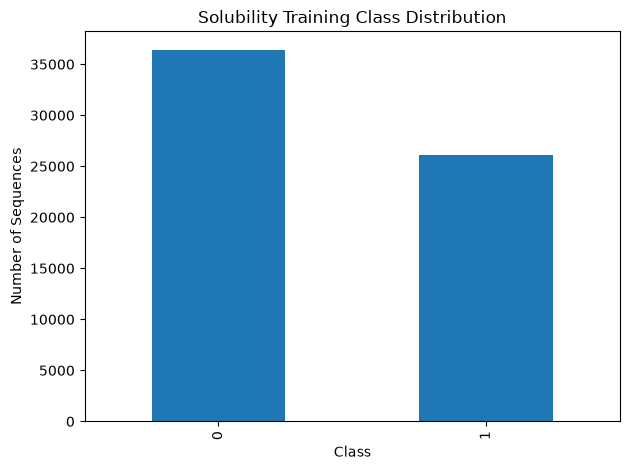

In [8]:
train_sol_counts = (
    solubility.loc[solubility["split"] == "train",  LABEL_COLUMN]
    .value_counts()
    .sort_index()
)

train_sol_counts.plot(kind="bar")
plt.title("Solubility Training Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Sequences")
plt.tight_layout()
plt.show()

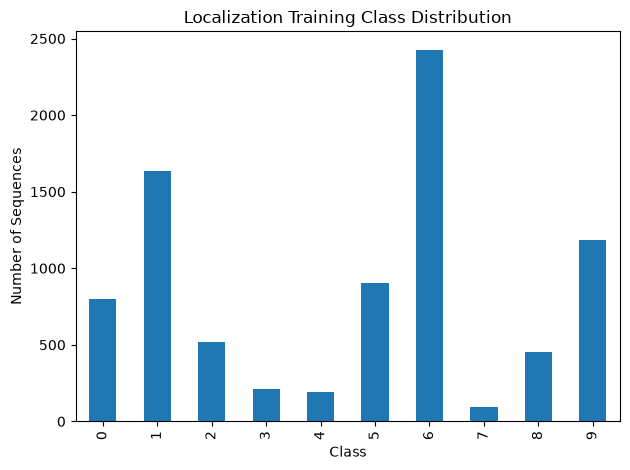

In [9]:
train_loc_counts = (
    localization.loc[localization["split"] == "train",  LABEL_COLUMN]
    .value_counts()
    .sort_index()
)

train_loc_counts.plot(kind="bar")
plt.title("Localization Training Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Sequences")
plt.tight_layout()
plt.show()

#### Sequence length analysis

In [10]:
for dataframe in (solubility, localization):
    dataframe["sequence_length"] = dataframe[SEQUENCE_COLUMN].str.len()

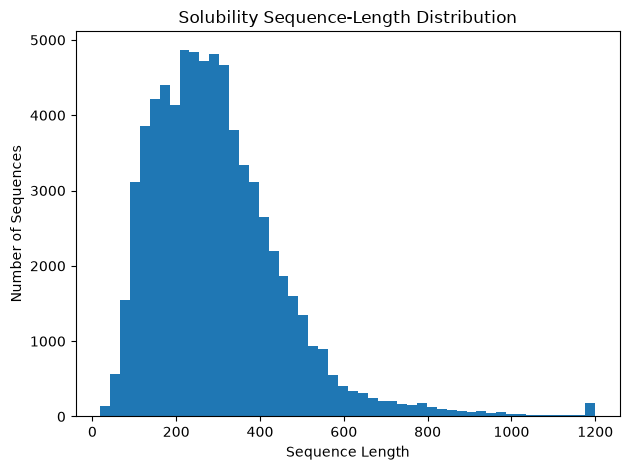

In [11]:
solubility["sequence_length"].plot(
    kind="hist",
    bins=50,
)
plt.title("Solubility Sequence-Length Distribution")
plt.xlabel("Sequence Length")
plt.ylabel("Number of Sequences")
plt.tight_layout()
plt.show()

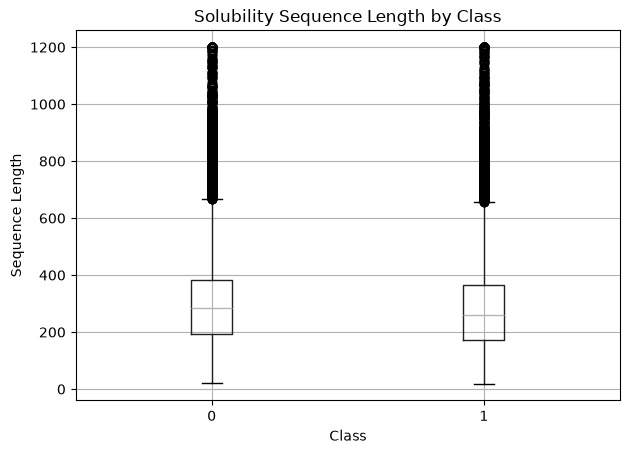

In [12]:
solubility.boxplot(
    column="sequence_length",
    by=LABEL_COLUMN,
)
plt.title("Solubility Sequence Length by Class")
plt.suptitle("")
plt.xlabel("Class")
plt.ylabel("Sequence Length")
plt.tight_layout()
plt.show()

#### Class Weights and Wighted Sampling

In [13]:
def calculate_weights(
    labels: pd.Series,
) -> tuple[np.ndarray, torch.Tensor]:
    classes = np.sort(labels.unique())

    weights = compute_class_weight(
        class_weight="balanced",
        classes = classes,
        y = labels.to_numpy(),
    )
    return classes, torch.tensor(weights, dtype=torch.float32)

In [14]:
sol_train_labels = solubility.loc[
    solubility["split"] == "train",
    LABEL_COLUMN,
]

sol_classes, sol_class_weights = calculate_weights(sol_train_labels)

sol_weight_table = pd.DataFrame(
    {
        "class": sol_classes,
        "class_weight": sol_class_weights.numpy(),
        "count": [
            (sol_train_labels == label).sum()
            for label in sol_classes
        ],
    }
)

display(sol_weight_table)

,class,class_weight,count
0,0,0.858144,36403
1,1,1.198044,26075


In [15]:
loc_train_labels = localization.loc[
    localization["split"] == "train",
    LABEL_COLUMN,
]

loc_classes, loc_class_weights = calculate_weights(loc_train_labels)

loc_weight_table = pd.DataFrame(
    {
        "class": loc_classes,
        "class_weight": loc_class_weights.numpy(),
        "count": [
            (loc_train_labels == label).sum()
            for label in loc_classes
        ],
    }
)

display(loc_weight_table)

,class,class_weight,count
0,0,1.052500,800
1,1,0.514985,1635
2,2,1.631783,516
3,3,3.934579,214
4,4,4.385417,192
5,5,0.929360,906
6,6,0.347073,2426
7,7,9.053763,93
8,8,1.858720,453
9,9,0.710549,1185


In [17]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

criterion = torch.nn.CrossEntropyLoss(
    weight=sol_class_weights.to(device)
)

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

criterion = torch.nn.CrossEntropyLoss(
    weight= loc_class_weights.to(device)
)

#### Create sampler weights

In [ ]:
def create_sample_weights(labels: pd.Series) -> torch.Tensor:
    class_counts = labels.value_counts().sort_index()
    inverse_frequency = 1.0 / class_counts

    sample_weights = labels.map(inverse_frequency).to_numpy()

    return torch.tensor(
        sample_weights,
        dtype=torch.double,
    )


sol_sample_weights = create_sample_weights(sol_train_labels)

sol_sampler = WeightedRandomSampler(
    weights= sol_sample_weights.tolist(),
    num_samples=len(sol_sample_weights),
    replacement=True,
)


print("Number of sampler weights:", len(sol_sample_weights))
print("First five weights:", sol_sample_weights[:5])

Number of sampler weights: 62478
First five weights: tensor([3.8351e-05, 2.7470e-05, 2.7470e-05, 2.7470e-05, 2.7470e-05],
       dtype=torch.float64)


In [ ]:
loc_sample_weights = create_sample_weights(loc_train_labels)

loc_sampler = WeightedRandomSampler(
    weights= loc_sample_weights.tolist(),
    num_samples=len(loc_sample_weights),
    replacement=True
)

print("Number of sampler weights:", len(loc_sample_weights))
print("First five weights:", loc_sample_weights[:5])

#### Training History Dashboard

In [29]:
history_files = sorted(
    RESULTS_ROOT.rglob("history.json")
)

print(f"Found {len(history_files)} history files.")

for path in history_files[:10]:
    print(path.relative_to(PROJECT_ROOT))

Found 12 history files.
Code/results/esm2/localization/cnn/stage0_frozen/esm2_localization_20260709_030334/history.json
Code/results/esm2/localization/cnn/stage1_unfreeze_last1/esm2_localization_20260711_223659/history.json
Code/results/esm2/localization/cnn/stage2_unfreeze_last2/esm2_localization_20260712_023756/history.json
Code/results/esm2/localization/cnn/stage_full_unfreeze/esm2_localization_20260712_041158/history.json
Code/results/esm2/solubility/cnn/stage0_frozen/esm2_solubility_20260615_032334/history.json
Code/results/esm2/solubility/cnn/stage0_frozen/esm2_solubility_20260623_155220/history.json
Code/results/esm2/solubility/cnn/stage0_frozen/esm2_solubility_20260706_204839/history.json
Code/results/esm2/solubility/cnn/stage1_unfreeze_last1/esm2_solubility_20260624_043923/history.json
Code/results/esm2/solubility/cnn/stage2_unfreeze_last2/history.json
Code/results/esm2/solubility/cnn/stage_full_unfreeze/esm2_solubility_20260708_221745/history.json


#### Benchmark Table

In [ ]:
def load_benchmark_record(path: Path) -> dict:
    with open(path, "r") as file:
        history = json.load(file)

    hyperparameters = history.get("hyperparameters", {})
    summary = history.get("summary", {})

    return {
        "run_path": str(path.parent.relative_to(PROJECT_ROOT)),
        "dataset": hyperparameters.get("dataset"),
        "classifier_head": hyperparameters.get("classifier_head"),
        "fine_tuning_strategy": hyperparameters.get(
            "fine_tuning_strategy"
        ),
        "learning_rate": hyperparameters.get("learning_rate"),
        "esm_learning_rate": hyperparameters.get(
            "esm_learning_rate"
        ),
        "best_epoch": summary.get("best_epoch"),
        "epochs_trained": summary.get("epochs_trained"),
        "best_val_loss": summary.get("best_val_loss"),
        "best_val_accuracy": summary.get("best_val_accuracy"),
        "best_val_f1": summary.get("best_val_f1"),
        "best_val_precision": summary.get(
            "best_val_precision"
        ),
        "best_val_recall": summary.get("best_val_recall"),
    }


benchmark_df = pd.DataFrame(
    load_benchmark_record(path)
    for path in history_files
)

benchmark_df = benchmark_df.dropna(
    subset=["dataset", "fine_tuning_strategy"]
)

benchmark_df = benchmark_df.sort_values(
    ["dataset", "best_val_f1"],
    ascending=[True, False],
)




display(benchmark_df)

,run_path,dataset,classifier_head,fine_tuning_strategy,learning_rate,esm_learning_rate,best_epoch,epochs_trained,best_val_loss,best_val_accuracy,best_val_f1,best_val_precision,best_val_recall
3,Code/results/esm2/localization/cnn/stage_full_...,localization,cnn,full_backbone,0.0001,0.000001,9,10.0,0.745176,0.764497,0.598820,0.691692,0.596660
0,Code/results/esm2/localization/cnn/stage0_froz...,localization,cnn,frozen_backbone,0.0010,0.000010,9,10.0,0.770927,0.746354,0.581699,0.592576,0.582915
2,Code/results/esm2/localization/cnn/stage2_unfr...,localization,cnn,last_2_layers,0.0001,0.000001,10,10.0,0.758442,0.740662,0.561182,0.604509,0.564374
1,Code/results/esm2/localization/cnn/stage1_unfr...,localization,cnn,last_1_layers,0.0001,0.000001,10,10.0,0.768057,0.736748,0.557852,0.607733,0.560334
9,Code/results/esm2/solubility/cnn/stage_full_un...,solubility,cnn,full_backbone,0.0001,0.000001,8,10.0,0.456508,0.773120,0.762904,0.775854,0.759565
8,Code/results/esm2/solubility/cnn/stage2_unfree...,solubility,cnn,last_2_layers,0.0001,0.000001,9,10.0,0.459675,0.772688,0.761741,0.771099,0.757970
10,Code/results/esm2/solubility/gru/stage0_frozen...,solubility,gru,frozen_backbone,0.0010,0.000010,4,9.0,0.466426,0.766782,0.759443,0.765197,0.760238
6,Code/results/esm2/solubility/cnn/stage0_frozen...,solubility,cnn,frozen_backbone,0.0010,0.000010,8,10.0,0.463135,0.769663,0.756179,0.773085,0.751453
11,Code/results/esm2/solubility/lstm/stage0_froze...,solubility,lstm,frozen_backbone,0.0010,0.000010,3,8.0,0.468263,0.759867,0.752124,0.759528,0.751181
7,Code/results/esm2/solubility/cnn/stage1_unfree...,NaN,NaN,NaN,0.0001,NaN,9,NaN,0.452688,0.773552,0.760615,0.774390,0.757391


## Training Analysis
### Learning Curve
- Below are the Learning curves of each run

In [ ]:
selected_rows = benchmark_df[
    (benchmark_df["dataset"] == "localization")
    & (benchmark_df["classifier_head"] == "cnn")
    & (benchmark_df["fine_tuning_strategy"] == "full_backbone")
]

selected_history_path = history_files[1]

with open(selected_history_path, "r") as file:
    selected_history = json.load(file)

epochs_df = pd.DataFrame(selected_history["epochs"])
display(epochs_df.head(10))

,epoch,train_loss,train_accuracy,train_f1,train_precision,train_recall,val_loss,val_accuracy,val_f1,val_precision,val_recall
0,1,1.820168,0.373278,0.173155,0.185240,0.190513,1.303529,0.565635,0.291468,0.270272,0.330637
1,2,1.308397,0.550238,0.300399,0.376109,0.324198,1.042922,0.622910,0.343985,0.348354,0.378813
2,3,1.131545,0.610926,0.379844,0.427150,0.391325,0.951670,0.659196,0.396264,0.376455,0.423232
3,4,1.030673,0.640974,0.420825,0.477710,0.426382,0.900210,0.676272,0.428672,0.483070,0.443878
4,5,0.977500,0.662114,0.441510,0.466765,0.448277,0.868476,0.700462,0.482693,0.494309,0.488205
5,6,0.929825,0.684442,0.474628,0.522010,0.480663,0.853486,0.705087,0.492968,0.495300,0.499853
6,7,0.888362,0.698337,0.491629,0.536649,0.496262,0.819396,0.721096,0.507525,0.511244,0.513112
7,8,0.850524,0.715202,0.511122,0.540452,0.516671,0.795425,0.725365,0.524921,0.590370,0.523711
8,9,0.813037,0.729929,0.529643,0.573592,0.533564,0.784707,0.729989,0.545874,0.607733,0.540636
9,10,0.783640,0.737767,0.537963,0.583187,0.541887,0.768057,0.736748,0.557852,0.587405,0.560334


Loss:

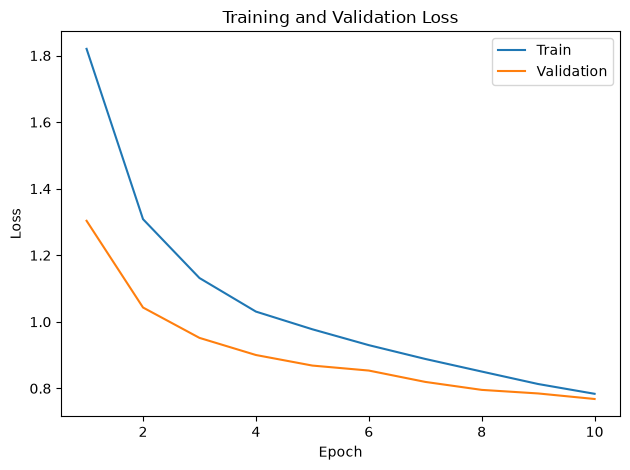

In [27]:
plt.plot(
    epochs_df["epoch"],
    epochs_df["train_loss"],
    label="Train",
)
plt.plot(
    epochs_df["epoch"],
    epochs_df["val_loss"],
    label="Validation",
)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.tight_layout()
plt.show()

Accuracy:

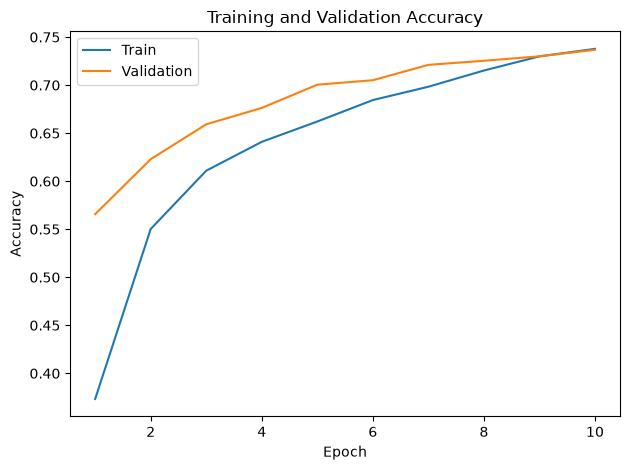

In [28]:
plt.plot(
    epochs_df["epoch"],
    epochs_df["train_accuracy"],
    label="Train",
)
plt.plot(
    epochs_df["epoch"],
    epochs_df["val_accuracy"],
    label="Validation",
)
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.tight_layout()
plt.show()

#### Class Weights and Weighted Sampling

Class Weights --> CrossEntropyLoss

Sample Weights --> WeightedRandomSampler